# 1. Problem Statement and Dataset

The goal of this project is to build a binary classification model that predicts whether a person is a smoker based on routine health examination data. The dataset comes from a health screening context and includes demographic variables (such as age, height, and weight), body measurements (for example, waist circumference), blood pressure, blood chemistry (cholesterol, triglycerides, liver enzymes, etc.), and oral health information. The target variable is `smoking`, which indicates whether the participant is a current smoker.

This problem is important because smoking is a major risk factor for a wide range of chronic diseases, including cardiovascular disease and cancer. Accurately identifying individuals who are likely to be smokers from existing medical data can help public health organizations and healthcare providers better understand risk patterns, design targeted interventions, and potentially reduce the burden of smoking-related diseases.

The competition evaluates models using the ROC-AUC (Area Under the Receiver Operating Characteristic Curve) metric. ROC-AUC measures how well the model ranks positive examples (smokers) ahead of negative examples (non-smokers) across all classification thresholds. This makes ROC-AUC a more informative metric than simple accuracy in this setting, especially if the classes are not perfectly balanced.


In [1]:
# All the required modules are imported here
#import cmle
#import mglearn
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from IPython.display import YouTubeVideo
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from lightgbm.sklearn import LGBMClassifier
from xgboost import XGBClassifier



#import opendatasets as od

from scipy.stats import loguniform, uniform
from sklearn import set_config
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(PrecisionRecallDisplay, 
                            classification_report, 
                            confusion_matrix, 
                            make_scorer, 
                            roc_curve, 
                            ConfusionMatrixDisplay,
                            precision_recall_curve,
                           )
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, average_precision_score, roc_auc_score



warnings.filterwarnings('ignore')
plt.rcParams["font.size"] = 16
pd.set_option("display.max_colwidth", 200)

import os
# Dictionary to store all paths
data_paths = {}

warnings.filterwarnings('ignore')
np.random.seed(42)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        data_paths[filename] = full_path
        print(full_path)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Access paths from dictionary
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,...,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,...,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,...,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,...,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,...,44,93,15.4,1,0.8,19,13,17,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159251,159251,40,155,45,69.0,1.5,2.0,1,1,127,...,72,159,14.5,1,0.8,25,26,13,0,0
159252,159252,50,155,75,82.0,1.0,1.0,1,1,120,...,64,108,14.5,1,0.6,21,20,18,0,0
159253,159253,40,160,50,66.0,1.5,1.0,1,1,114,...,87,93,10.9,1,0.6,15,9,12,0,0
159254,159254,50,165,75,92.0,1.2,1.0,1,1,121,...,55,80,14.4,1,1.1,22,17,37,0,1


In [4]:
#Viewing the test data
test_df

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,159256,40,165,70,84.0,1.2,1.2,1,1,130,...,186,49,115,14.2,1,0.9,19,25,32,0
1,159257,80,160,60,93.0,1.0,1.0,2,2,144,...,158,35,104,13.0,1,1.1,20,12,24,0
2,159258,60,170,70,86.5,0.6,0.7,1,1,117,...,173,39,88,15.4,1,1.4,38,60,36,0
3,159259,40,160,50,67.0,0.3,0.4,1,1,116,...,47,75,128,14.5,1,0.6,25,18,10,1
4,159260,40,170,75,89.4,1.0,0.9,1,1,132,...,100,39,123,16.5,1,1.0,30,39,27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106166,265422,40,165,60,78.0,0.8,0.9,1,1,112,...,82,59,149,16.4,1,1.1,24,31,28,0
106167,265423,40,170,85,95.0,1.2,1.2,1,1,130,...,186,44,100,16.0,2,1.0,25,31,38,0
106168,265424,35,170,85,89.0,1.2,1.2,1,1,131,...,76,53,142,15.9,1,0.8,33,32,24,1
106169,265425,40,160,60,67.0,0.7,0.8,1,1,120,...,81,55,103,13.9,1,0.6,42,36,32,0


# 2. Exploratory Data Analysis (EDA)

We began by inspecting the structure of the training and test datasets using `info()` and `describe(include="all")`. This allowed us to confirm data types, look for obvious data quality issues, and get a first sense of the distributions of the features and the target variable. We did not observe any problematic missing values, so we proceeded without additional imputation.

Next, we created histograms for key numeric features such as age, height, weight, waist circumference, blood pressure (systolic and diastolic), blood sugar, cholesterol-related variables (total cholesterol, HDL, LDL, triglycerides), liver enzymes (AST, ALT, Gtp), and the `dental caries` indicator. These plots helped us see the overall shape and spread of the data (for example, whether variables were roughly normal, skewed, or had outliers). They also gave some intuition for which variables might differ meaningfully between smokers and non-smokers.

To understand linear relationships between features, we computed a correlation matrix on the training features and visualized it as a heatmap. This revealed several strong correlations. In particular, `waist(cm)` was highly correlated with other body-size measures such as weight, and `LDL` was highly correlated with total cholesterol and other lipid measurements. Because highly collinear features can add noise without much new information, we used this EDA step to inform our feature selection decisions.


In [5]:
# Exploring the training data
train_df.info()
train_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   159256 non-null  int64  
 1   age                  159256 non-null  int64  
 2   height(cm)           159256 non-null  int64  
 3   weight(kg)           159256 non-null  int64  
 4   waist(cm)            159256 non-null  float64
 5   eyesight(left)       159256 non-null  float64
 6   eyesight(right)      159256 non-null  float64
 7   hearing(left)        159256 non-null  int64  
 8   hearing(right)       159256 non-null  int64  
 9   systolic             159256 non-null  int64  
 10  relaxation           159256 non-null  int64  
 11  fasting blood sugar  159256 non-null  int64  
 12  Cholesterol          159256 non-null  int64  
 13  triglyceride         159256 non-null  int64  
 14  HDL                  159256 non-null  int64  
 15  LDL              

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,...,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000
mean,79627.500000,44.306626,165.266929,67.143662,83.001990,1.005798,1.000989,1.023974,1.023421,122.503648,...,55.852684,114.607682,14.796965,1.074233,0.892764,25.516853,26.550296,36.216004,0.197996,0.437365
std,45973.391572,11.842286,8.818970,12.586198,8.957937,0.402113,0.392299,0.152969,0.151238,12.729315,...,13.964141,28.158931,1.431213,0.347856,0.179346,9.464882,17.753070,31.204643,0.398490,0.496063
min,0.000000,20.000000,135.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,77.000000,...,9.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,39813.750000,40.000000,160.000000,60.000000,77.000000,0.800000,0.800000,1.000000,1.000000,114.000000,...,45.000000,95.000000,13.800000,1.000000,0.800000,20.000000,16.000000,18.000000,0.000000,0.000000
50%,79627.500000,40.000000,165.000000,65.000000,83.000000,1.000000,1.000000,1.000000,1.000000,121.000000,...,54.000000,114.000000,15.000000,1.000000,0.900000,24.000000,22.000000,27.000000,0.000000,0.000000
75%,119441.250000,55.000000,170.000000,75.000000,89.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,64.000000,133.000000,15.800000,1.000000,1.000000,29.000000,32.000000,44.000000,0.000000,1.000000
max,159255.000000,85.000000,190.000000,130.000000,127.000000,9.900000,9.900000,2.000000,2.000000,213.000000,...,136.000000,1860.000000,21.000000,6.000000,9.900000,778.000000,2914.000000,999.000000,1.000000,1.000000


In [6]:
# Exploring the testing data
test_df.info()
test_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106171 entries, 0 to 106170
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   106171 non-null  int64  
 1   age                  106171 non-null  int64  
 2   height(cm)           106171 non-null  int64  
 3   weight(kg)           106171 non-null  int64  
 4   waist(cm)            106171 non-null  float64
 5   eyesight(left)       106171 non-null  float64
 6   eyesight(right)      106171 non-null  float64
 7   hearing(left)        106171 non-null  int64  
 8   hearing(right)       106171 non-null  int64  
 9   systolic             106171 non-null  int64  
 10  relaxation           106171 non-null  int64  
 11  fasting blood sugar  106171 non-null  int64  
 12  Cholesterol          106171 non-null  int64  
 13  triglyceride         106171 non-null  int64  
 14  HDL                  106171 non-null  int64  
 15  LDL              

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
count,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,...,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000,106171.000000
mean,212341.000000,44.426538,165.221322,67.125618,82.999892,1.004776,0.999483,1.024216,1.023980,122.475403,...,127.406203,55.922286,114.597404,14.793354,1.072798,0.892463,25.559616,26.565427,36.086888,0.195458
std,30649.072052,11.897138,8.837065,12.586569,8.946584,0.397690,0.385752,0.153719,0.152988,12.765542,...,66.352488,14.000552,26.943401,1.434296,0.340818,0.179927,9.504442,17.944195,30.928138,0.396555
min,159256.000000,20.000000,135.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,...,8.000000,18.000000,1.000000,5.000000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000
25%,185798.500000,40.000000,160.000000,60.000000,77.000000,0.800000,0.800000,1.000000,1.000000,114.000000,...,77.000000,45.000000,95.000000,13.800000,1.000000,0.800000,20.000000,16.000000,18.000000,0.000000
50%,212341.000000,40.000000,165.000000,65.000000,83.000000,1.000000,1.000000,1.000000,1.000000,121.000000,...,114.000000,54.000000,114.000000,15.000000,1.000000,0.900000,24.000000,22.000000,27.000000,0.000000
75%,238883.500000,55.000000,170.000000,75.000000,89.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,164.000000,64.000000,133.000000,15.800000,1.000000,1.000000,29.000000,33.000000,44.000000,0.000000
max,265426.000000,85.000000,190.000000,130.000000,127.700000,9.900000,9.900000,2.000000,2.000000,213.000000,...,548.000000,148.000000,1220.000000,21.100000,6.000000,9.900000,778.000000,2914.000000,999.000000,1.000000


array([[<AxesSubplot: title={'center': 'age'}>,
        <AxesSubplot: title={'center': 'height(cm)'}>,
        <AxesSubplot: title={'center': 'weight(kg)'}>,
        <AxesSubplot: title={'center': 'waist(cm)'}>,
        <AxesSubplot: title={'center': 'eyesight(left)'}>],
       [<AxesSubplot: title={'center': 'eyesight(right)'}>,
        <AxesSubplot: title={'center': 'hearing(left)'}>,
        <AxesSubplot: title={'center': 'hearing(right)'}>,
        <AxesSubplot: title={'center': 'systolic'}>,
        <AxesSubplot: title={'center': 'relaxation'}>],
       [<AxesSubplot: title={'center': 'fasting blood sugar'}>,
        <AxesSubplot: title={'center': 'Cholesterol'}>,
        <AxesSubplot: title={'center': 'triglyceride'}>,
        <AxesSubplot: title={'center': 'HDL'}>,
        <AxesSubplot: title={'center': 'LDL'}>],
       [<AxesSubplot: title={'center': 'hemoglobin'}>,
        <AxesSubplot: title={'center': 'Urine protein'}>,
        <AxesSubplot: title={'center': 'serum creatinin

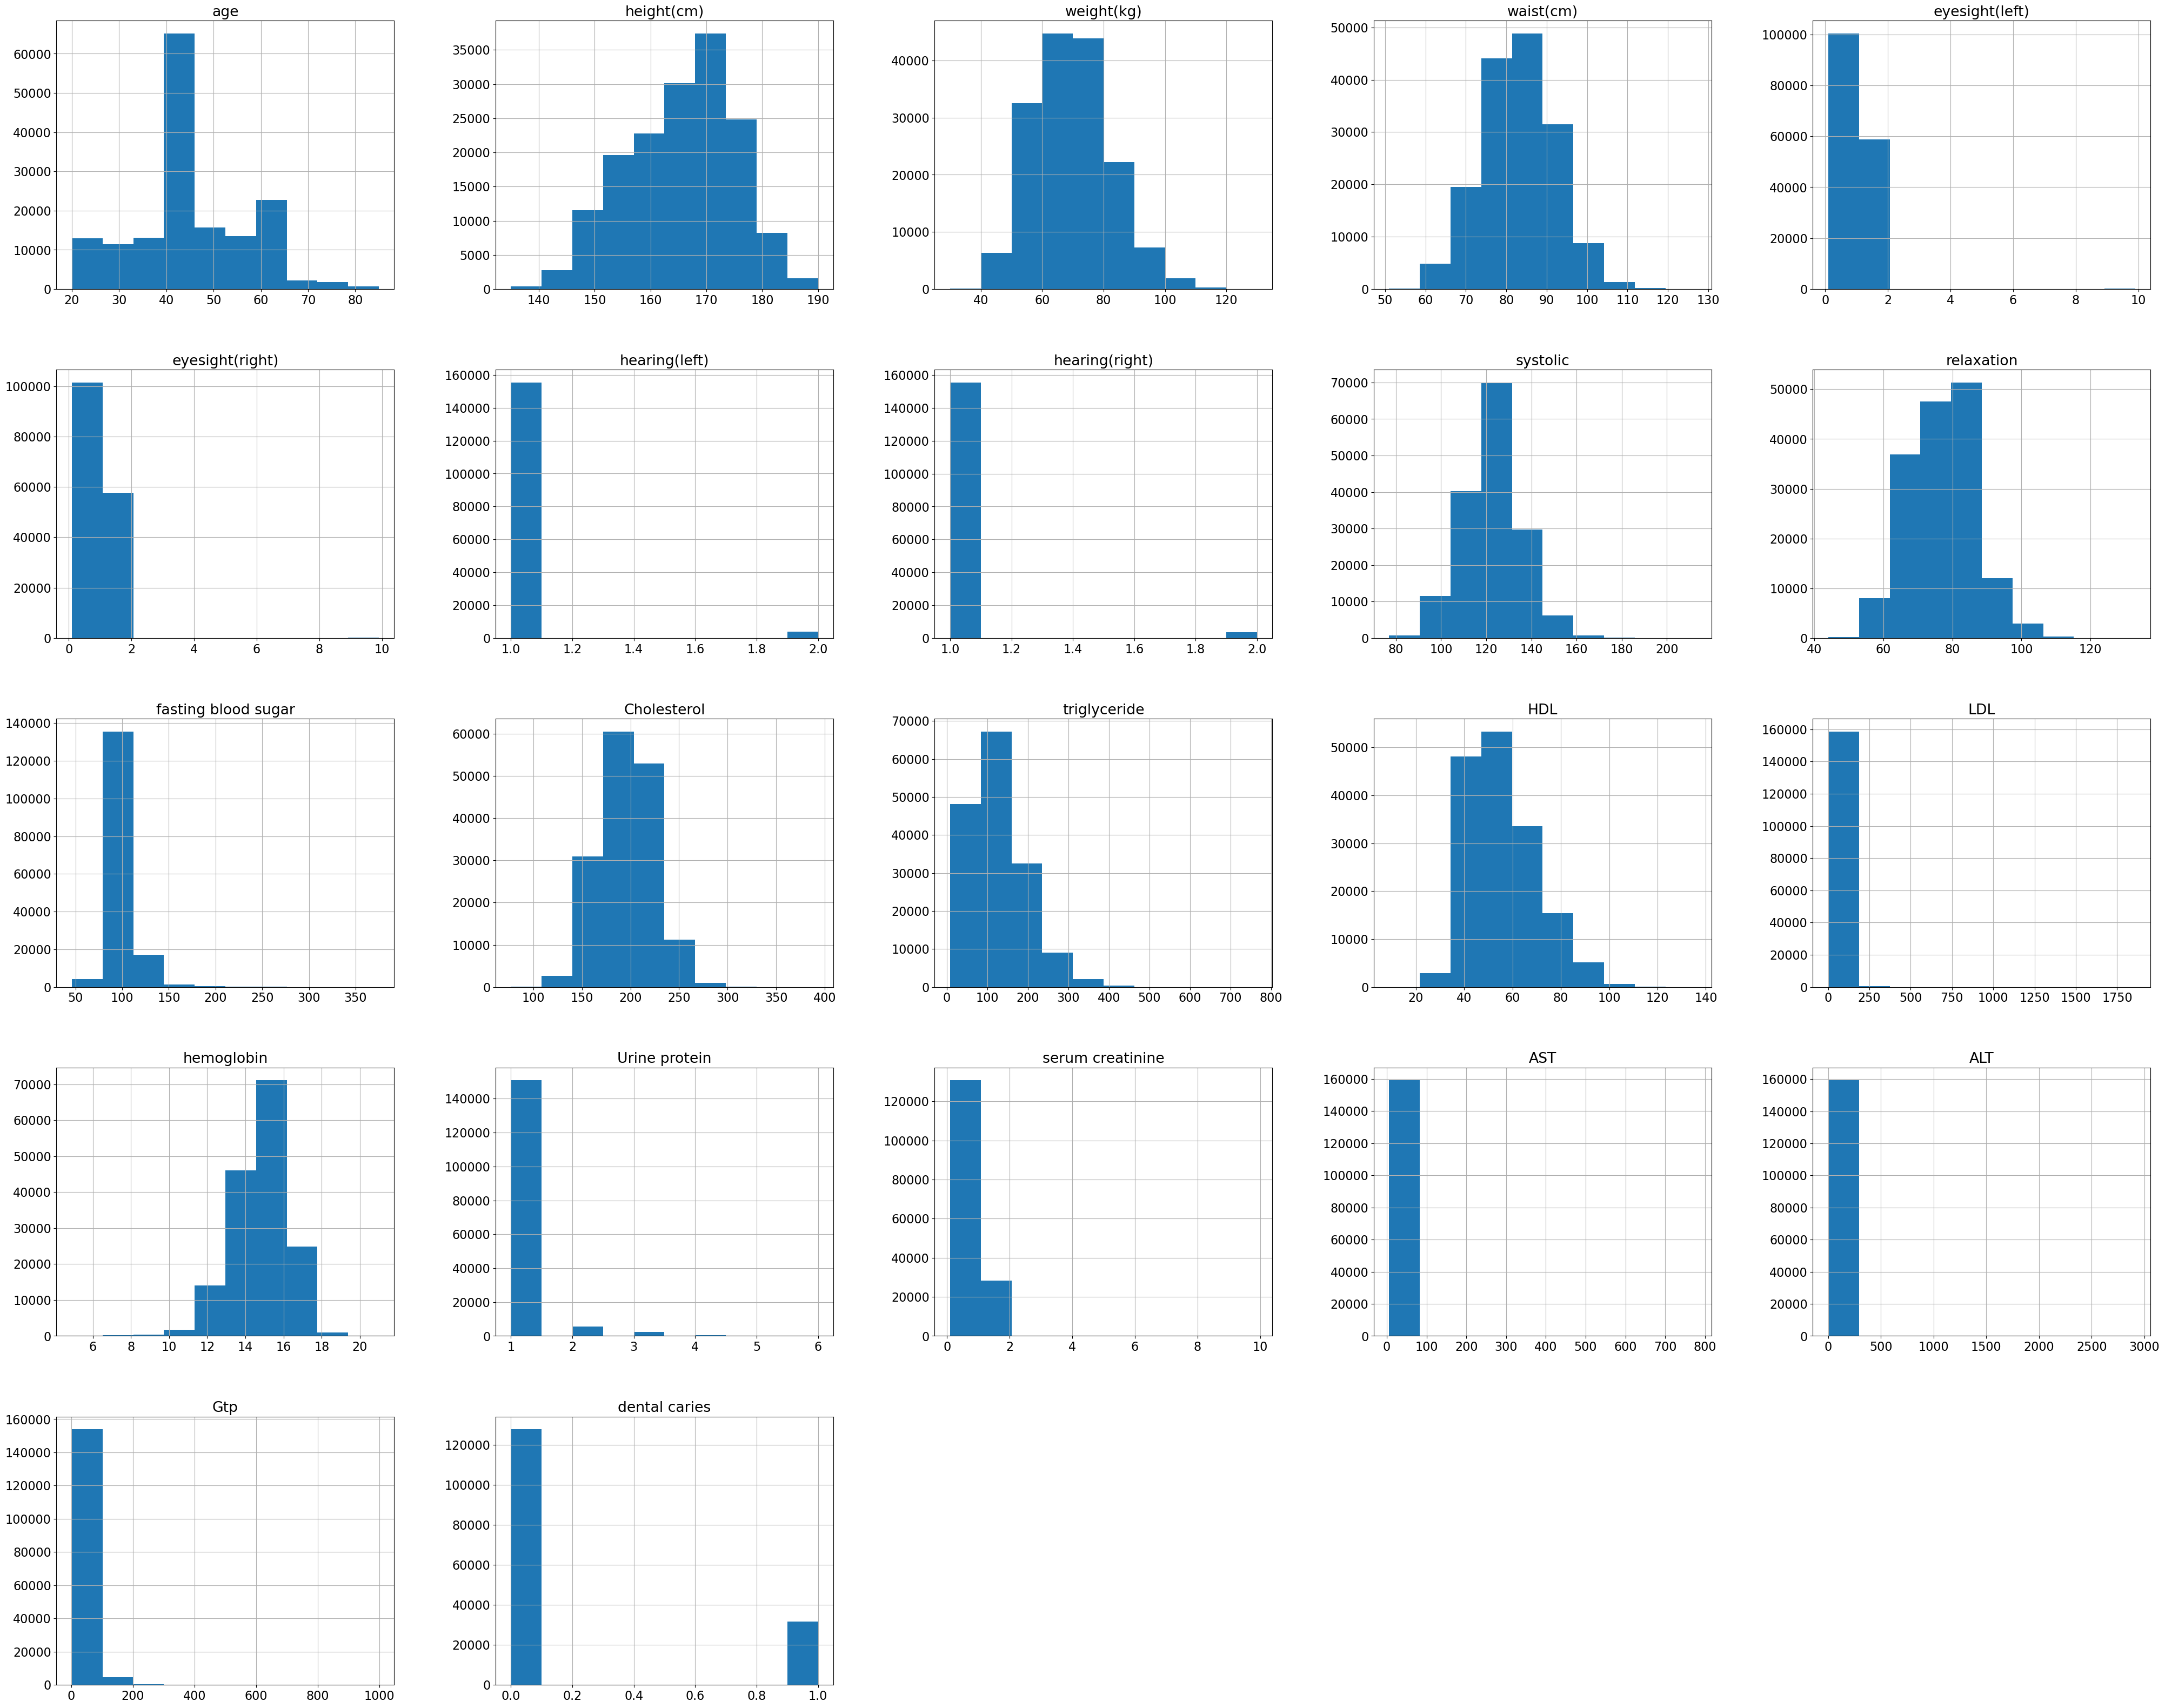

In [7]:
# Plotting the feature data
train_df.hist(column=['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries'], bins=10, figsize=(50,40))

# 3. Preprocessing and Feature Engineering

Based on our EDA, we constructed the feature matrix and target vector for modeling. We dropped the `id` column because it is simply a unique identifier and does not contain predictive information. The target variable `y_train` was defined as the `smoking` column, and the remaining feature columns formed our initial `X_train`. For the test set, we similarly removed only the `id` column to form `X_test`.

To reduce multicollinearity, we removed `waist(cm)` and `LDL` from the feature set. These variables were strongly correlated with other body-size and lipid features in the correlation heatmap, so keeping all of them would likely provide redundant information. Dropping a small number of highly correlated features simplifies the model without sacrificing much predictive power.

Before fitting most of our models, we applied standardization using `StandardScaler`. We fit the scaler on the training split and then transformed both the training split and the held-out test split. Standardization centers each numeric feature to have mean zero and unit variance. This step is especially important for distance-based models like k-Nearest Neighbors and for models whose optimization behaves better when features are on comparable scales, such as logistic regression and some tree-based ensemble methods when used in pipelines.


In [8]:
#Creating training dataset
#id is unique featue, so we dropped it.
X_train = train_df.drop(columns=["id", "smoking"])
y_train = train_df["smoking"]

# Creating testing dataset
X_test = test_df.drop(columns=["id"])
X_test.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,40,165,70,84.0,1.2,1.2,1,1,130,89,...,186,49,115,14.2,1,0.9,19,25,32,0
1,80,160,60,93.0,1.0,1.0,2,2,144,72,...,158,35,104,13.0,1,1.1,20,12,24,0
2,60,170,70,86.5,0.6,0.7,1,1,117,75,...,173,39,88,15.4,1,1.4,38,60,36,0
3,40,160,50,67.0,0.3,0.4,1,1,116,62,...,47,75,128,14.5,1,0.6,25,18,10,1
4,40,170,75,89.4,1.0,0.9,1,1,132,94,...,100,39,123,16.5,1,1.0,30,39,27,1


<AxesSubplot: >

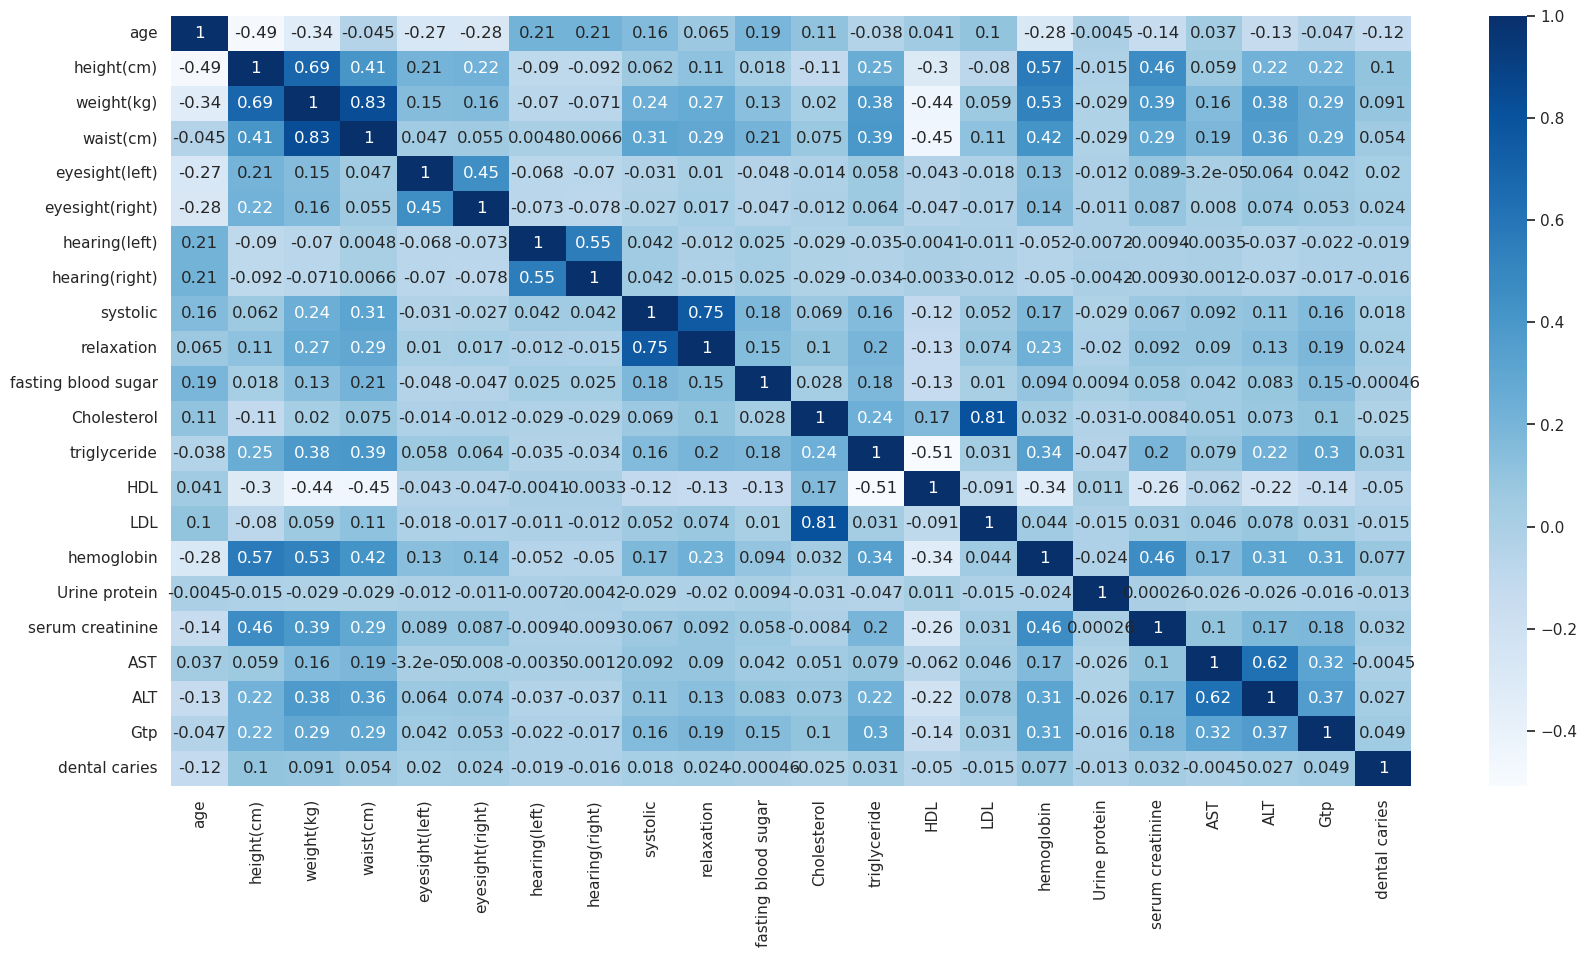

In [9]:
#Generating the heat map on train data set
cor = X_train.corr()
plt.figure(figsize=(20, 10))
sns.set(font_scale=1)
sns.heatmap(cor, annot=True, cmap=plt.cm.Blues)

In [10]:
#From the correlation mapping, we can see there are strong correlation between weight and waist, cholesterol and LDL. So, we will 
#drop the waist and LDL feature for decreasing the complexity.

X_train_modified = X_train.drop(columns=["waist(cm)","LDL"])
X_test_modified = X_test.drop(columns=["waist(cm)","LDL"])
X_train_modified.head()

,age,height(cm),weight(kg),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,55,165,60,0.5,0.6,1,1,135,87,94,172,300,40,16.5,1,1.0,22,25,27,0
1,70,165,65,0.6,0.7,2,2,146,83,147,194,55,57,16.2,1,1.1,27,23,37,1
2,20,170,75,0.4,0.5,1,1,118,75,79,178,197,45,17.4,1,0.8,27,31,53,0
3,35,180,95,1.5,1.2,1,1,131,88,91,180,203,38,15.9,1,1.0,20,27,30,1
4,30,165,60,1.5,1.0,1,1,121,76,91,155,87,44,15.4,1,0.8,19,13,17,0


In [11]:
#train-test split done at 80:20 ratio.
X_train_split, X_test_split, y_train, y_test_split = train_test_split(X_train_modified, y_train, test_size=0.2, random_state=123)

In [12]:
# Applying Scaling (StandardScaler) to both training and test data. 
# Although it is not needed for dummy classifier, we tend to use some preprocessing techniques

scaler = StandardScaler()  # Apply Scaling
scaler.fit(X_train_split)  # fitting the transformer on the train split
X_train_scaled = scaler.transform(X_train_split)  # transforming the train split
X_test_split_scaled = scaler.transform(X_test_split) # transforming the test split
X_test_scaled = scaler.transform(X_test_modified)  # transforming the test set for kaggle
pd.DataFrame(X_train_scaled, columns=X_train_modified.columns).head()

,age,height(cm),weight(kg),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,-0.785625,0.536615,-0.168387,-0.013523,1.281540,-0.155634,-0.154892,0.275554,-1.322063,0.630878,0.324993,-0.296517,1.080232,0.631842,-0.214904,0.600228,-1.000029,-0.540913,0.732281,-0.494797
1,-0.363735,-0.029593,-0.963332,-0.013523,-0.258835,-0.155634,-0.154892,-1.532729,-0.653915,1.284615,-0.273614,-0.629665,0.221995,0.282853,-0.214904,0.040318,-0.159110,-0.313778,0.057392,-0.494797
2,0.901935,-1.162009,-0.168387,-0.763385,-1.029022,-0.155634,-0.154892,0.825902,0.682381,-0.938090,0.078508,0.369777,-0.922321,-1.392292,-0.214904,-1.639412,0.681808,0.026924,-0.810323,-0.494797
3,1.323825,-1.728217,-0.963332,-0.513431,-0.002106,-0.155634,-0.154892,2.162459,0.348307,-0.611222,-0.907433,-1.083956,0.221995,-0.484922,-0.214904,-1.639412,-0.579570,-0.370562,-0.681772,2.021031
4,1.323825,-0.029593,1.818973,-0.513431,-0.515564,-0.155634,-0.154892,-0.196172,-0.208483,1.415363,-0.731372,1.051214,-1.709038,-0.275528,-0.214904,1.720047,0.576694,0.992246,-0.103296,-0.494797


In [13]:
# Creating a dummy model and training the model
model = DummyClassifier(strategy="most_frequent")
model.fit(X_train_scaled, y_train)


DummyClassifier(strategy='most_frequent')

# 4. Models and Methodology

We experimented with a range of baseline and advanced classification models to understand which approaches work best on this tabular health dataset.

As a sanity check, we first trained a `DummyClassifier` using the "most_frequent" strategy. This model always predicts the majority class and gives us a very simple baseline for ROC–AUC, accuracy, and precision. Any meaningful model should outperform this dummy baseline.

For our main models, we trained:

- **Decision Tree Classifier**: We built a decision tree and tuned the `max_depth` hyperparameter using `GridSearchCV` over depths from 1 to 19 in steps of 2. This allowed us to control the complexity of the tree and reduce overfitting.
- **k-Nearest Neighbors (kNN)**: We explored different values of `n_neighbors`. Full grid search was too slow for the size of this dataset, so after experimentation we selected `k = 5`, which provided the best performance within reasonable compute time.
- **Logistic Regression**: We used a regularized logistic regression model and tuned the inverse regularization strength `C` over a range of values, as well as `class_weight` (testing both `None` and `"balanced"`). The grid search used 5-fold cross-validation with `scoring="f1"` to select a configuration that balances precision and recall. The best model used `C = 1.0` and `class_weight="balanced"`.
- **Random Forest Classifier**: We trained a random forest with `n_estimators=400` and `max_depth=18`. Random forests combine many decision trees and can capture nonlinear relationships and interactions while averaging out individual tree noise.
- **LightGBM Classifier**: We fit a `LGBMClassifier` with a fixed random seed. Gradient boosting methods like LightGBM often perform well on structured tabular data by iteratively adding trees that correct the errors of previous trees.
- **XGBoost Classifier**: We trained an `XGBClassifier` with a specified `random_state` and `eval_metric="logloss"`. XGBoost is another powerful gradient boosting method designed for efficiency and high performance on tabular datasets.

To evaluate models consistently, we used 5-fold cross-validation with `scoring="roc_auc"` via a helper function `mean_std_cross_val_scores`. For each model, we wrapped it in a `make_pipeline` with `StandardScaler` (where appropriate) and reported both the mean and standard deviation of the cross-validated ROC–AUC scores for the training data.

Finally, we trained an additional XGBoost model (`xgb_curve`) with `eval_metric="auc"` and an `eval_set` consisting of the scaled training and validation splits. We plotted the training and validation ROC–AUC over boosting rounds to visualize how performance evolved and to check for signs of overfitting.


In [14]:
# Score the model
model.score(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)[:, 1]

dummy_train_acc  = accuracy_score(y_train, y_train_pred)
dummy_train_prec = precision_score(y_train, y_train_pred)
dummy_train_roc  = roc_auc_score(y_train, y_train_proba)

print("Dummy Train ROC Score:", dummy_train_roc)
print("Dummy Train Accuracy:", dummy_train_acc)
print("Dummy Train Precision:", dummy_train_prec)

# --- Test metrics (use the same split as other models) ---
y_test_pred = model.predict(X_test_split_scaled)
y_test_proba = model.predict_proba(X_test_split_scaled)[:, 1]

dummy_test_acc  = accuracy_score(y_test_split, y_test_pred)
dummy_test_prec = precision_score(y_test_split, y_test_pred)
dummy_test_roc  = roc_auc_score(y_test_split, y_test_proba)

print("Dummy Test ROC Score:", dummy_test_roc)
print("Dummy Test Accuracy:", dummy_test_acc)
print("Dummy Test Precision:", dummy_test_prec)

Dummy Train ROC Score: 0.5
Dummy Train Accuracy: 0.5627766789111802
Dummy Train Precision: 0.0
Dummy Test ROC Score: 0.5
Dummy Test Accuracy: 0.5620683159613211
Dummy Test Precision: 0.0


In [15]:
# Predicting the test data
predicted = model.predict_proba(X_test_scaled)

#Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted[:,1], index = test_df.id).to_csv('first_submission.csv', sep=',', index=True, encoding='utf-8')

In [16]:
#creating the pipeline for Decision Tree classifier
#Implemented Grid search method to find out the best hyperparameter (max_depth)
pipe = make_pipeline(
    DecisionTreeClassifier(max_depth= None),
    )
param_grid = {
    "decisiontreeclassifier__max_depth": np.arange(1, 20, 2),
}

grid_search = GridSearchCV(pipe, param_grid, cv=5,
                           n_jobs=-1, return_train_score=True)

grid_search.fit(X_train_scaled, y_train)
print("Best Score from the Grid Search: " , grid_search.best_score_)
print("Best Parameters: " , grid_search.best_params_)

Best Score from the Grid Search:  0.7560908845369255
Best Parameters:  {'decisiontreeclassifier__max_depth': 7}


In [17]:
#From the grid search, we got the best max_depth value = 7.
#So, we trained the model using this value
pipe_tree = make_pipeline(DecisionTreeClassifier(max_depth=7))
pipe_tree.fit(X_train_scaled,y_train)
pipe_tree.score(X_train_scaled,y_train)

0.7608709302690654

In [18]:
# Predicting the test data
predicted = pipe_tree.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted[:,1], index = test_df.id).to_csv('decisiontree.csv', sep=',', index=True, encoding='utf-8')

In [19]:
#Predict and Evaluation on train split data Set
y_pred = pipe_tree.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("Decision Tree Train ROC Score:", roc_score)
print("Decision Tree Train Accuracy:", accuracy)
print("Decision Tree Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = pipe_tree.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("Decision Tree Test ROC Score:", roc_score)
print("Decision Tree Test Accuracy:", accuracy)
print("Decision Tree Test Precision:", precision)

Decision Tree Train ROC Score: 0.7664488281454215
Decision Tree Train Accuracy: 0.7608709302690654
Decision Tree Train Precision: 0.6938402457757297
Decision Tree Test ROC Score: 0.7619996271397405
Decision Tree Test Accuracy: 0.756216250156976
Decision Tree Test Precision: 0.6888359594479052


In [20]:
# Predicting the test data for Kaggle submission
predicted_proba = pipe_tree.predict_proba(X_test_scaled)

# Creating submission file
submission_dt = pd.DataFrame({
    'id': test_df.id,
    'target': predicted_proba[:, 1]
})
submission_dt.to_csv('decisionTree_submission.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!


In [21]:
# Create and Train the KNN Model
# We tried to find the best n_neighbors value using for loop and grid search
# but in both of the cases, it took like infinite time.
# Atfter trial and error of unique values we found the best score for n_neighbors = 5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [22]:
#Predict and Evaluation on train split data Set
y_pred = knn_model.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("KNN Train ROC Score:", roc_score)
print("KNN Train Accuracy:", accuracy)
print("KNN Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = knn_model.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("KNN Test ROC Score:", roc_score)
print("KNN Test Accuracy:", accuracy)
print("KNN Test Precision:", precision)

KNN Train ROC Score: 0.8178937744455601
KNN Train Accuracy: 0.8175645976578443
KNN Train Precision: 0.775321877491476
KNN Test ROC Score: 0.7303136728478657
KNN Test Accuracy: 0.7308489262840638
KNN Test Precision: 0.6806694448178519


In [23]:
# Predicting the test data
predicted_kNN = knn_model.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted_kNN[:,1], index = test_df.id).to_csv('kNN.csv', sep=',', index=True, encoding='utf-8')

In [24]:
# Predicting the test data for Kaggle submission
predicted_knn_proba = knn_model.predict_proba(X_test_scaled)

# Creating submission file
submission_knn = pd.DataFrame({
    'id': test_df.id,
    'target': predicted_knn_proba[:, 1]
})
submission_knn.to_csv('knn_submission.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!


In [25]:
# creating the pipeline for logistic regression
# implemented Grid search method to find out the best hyperparameters (C_vals, class_weight)

C_vals = 10.0 ** np.arange(-1.5, 2, 0.5)
class_weight_param = [None,'balanced']

pipe = make_pipeline(
        LogisticRegression(max_iter=1000, C=None, class_weight= None),
    )
param_grid = {
    "logisticregression__C": C_vals,
    "logisticregression__class_weight": class_weight_param,
}

grid_search = GridSearchCV(pipe, param_grid, cv=5,
                           n_jobs=-1, return_train_score=True, scoring = "f1")

grid_search.fit(X_train_scaled, y_train)
print("Best Score from the Grid Search: " , grid_search.best_score_)
print("Best Parameters: " , grid_search.best_params_)

Best Score from the Grid Search:  0.7423836362243639
Best Parameters:  {'logisticregression__C': 1.0, 'logisticregression__class_weight': 'balanced'}


In [26]:
# Build the best model
pipe_logistic = None

# BEGIN YOUR CODE
pipe_logistic = make_pipeline(LogisticRegression(C=1.0, class_weight= "balanced"))

pipe_logistic.fit(X_train_scaled, y_train)

Pipeline(steps=[('logisticregression',
                 LogisticRegression(class_weight='balanced'))])

In [27]:
#Predict and Evaluation on train split data Set
y_pred = pipe_logistic.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("Logistic Regression Train ROC Score:", roc_score)
print("Logistic Regression Train Accuracy:", accuracy)
print("Logistic Regression Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = pipe_logistic.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("Logistic Regression Test ROC Score:", roc_score)
print("Logistic Regression Test Accuracy:", accuracy)
print("Logistic Regression Test Precision:", precision)

Logistic Regression Train ROC Score: 0.7605669161623574
Logistic Regression Train Accuracy: 0.7543091268719977
Logistic Regression Train Precision: 0.6851891202719932
Logistic Regression Test ROC Score: 0.7589365280909947
Logistic Regression Test Accuracy: 0.7523546402109758
Logistic Regression Test Precision: 0.6826592730998734


In [28]:
# Predicting the test data
predicted_logistic = pipe_logistic.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted_logistic[:,1], index = test_df.id).to_csv('LogisticRegression.csv', sep=',', index=True, encoding='utf-8')

In [29]:
# Creating a pipeline with a RANDOMFORESTCLASSIFIER
# implemented Grid search method to find out the best hyperparameters (n_estimators, max_depth)
from sklearn.ensemble import RandomForestClassifier

pipe_rf = RandomForestClassifier(random_state=123)

# Define the ranges for hyperparameters n_estimators and max_depth
n_estimators = np.arange(100,500,50)
max_depth = np.arange(1,20,1)

param_grid = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
}

grid_search = RandomizedSearchCV(pipe_rf, param_distributions=param_grid, cv=5,
                           n_jobs=-1, return_train_score=True)

grid_search.fit(X_train_scaled, y_train)
print("Best Score from the Grid Search:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best Score from the Grid Search: 0.7771498688621811
Best Parameters: {'n_estimators': 200, 'max_depth': 19}


In [30]:
# Build the best model - RANDOMFORESTCLASSIFIER
pipe_ranfor = None

# BEGIN YOUR CODE
pipe_ranfor = make_pipeline(RandomForestClassifier(n_estimators=400, max_depth = 18,random_state=123))

pipe_ranfor.fit(X_train_scaled, y_train)

Pipeline(steps=[('randomforestclassifier',
                 RandomForestClassifier(max_depth=18, n_estimators=400,
                                        random_state=123))])

In [31]:
#Predict and Evaluation on train split data Set
y_pred = pipe_ranfor.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("Random Forest Train ROC Score:", roc_score)
print("Random Forest Train Accuracy:", accuracy)
print("Random Forest Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = pipe_ranfor.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("Random Forest Test ROC Score:", roc_score)
print("Random Forest Test Accuracy:", accuracy)
print("Random Forest Test Precision:", precision)

Random Forest Train ROC Score: 0.9306034556835684
Random Forest Train Accuracy: 0.9246177514049795
Random Forest Train Precision: 0.8665246151889072
Random Forest Test ROC Score: 0.7820068111687509
Random Forest Test Accuracy: 0.7768115032023107
Random Forest Test Precision: 0.7118434093161546


In [32]:
# Predicting the test data - RANDOMFORESTCLASSIFIER
predicted = pipe_ranfor.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted[:,1], index = test_df.id).to_csv('third_submission_randomforest.csv', sep=',', index=True, encoding='utf-8')

In [33]:
# Build the LGBM model
pipe_lgbm = None

pipe_lgbm = make_pipeline(LGBMClassifier(random_state=123))

pipe_lgbm.fit(X_train_scaled, y_train)

Pipeline(steps=[('lgbmclassifier', LGBMClassifier(random_state=123))])

In [34]:
#Predict and Evaluation on train split data Set
y_pred = pipe_lgbm.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("LGBM Train ROC Score:", roc_score)
print("LGBM Train Accuracy:", accuracy)
print("LGBM Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = pipe_lgbm.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("LGBM Test ROC Score:", roc_score)
print("LGBM Test Accuracy:", accuracy)
print("LGBM Test Precision:", precision)

LGBM Train ROC Score: 0.795007165790247
LGBM Train Accuracy: 0.7910426674201751
LGBM Train Precision: 0.7307875440434244
LGBM Test ROC Score: 0.7812400097934984
LGBM Test Accuracy: 0.77753359286701
LGBM Test Precision: 0.7176657151918807


In [35]:
# Predicting the test data
predicted = pipe_lgbm.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted[:,1], index = test_df.id).to_csv('lgbm.csv', sep=',', index=True, encoding='utf-8')

In [36]:
# Build the XGB model
pipe_xgb = None

pipe_xgb = make_pipeline(XGBClassifier(random_state=123, eval_metric="logloss", verbosity=0))

pipe_xgb.fit(X_train_scaled, y_train)

Pipeline(steps=[('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=123, ...))])

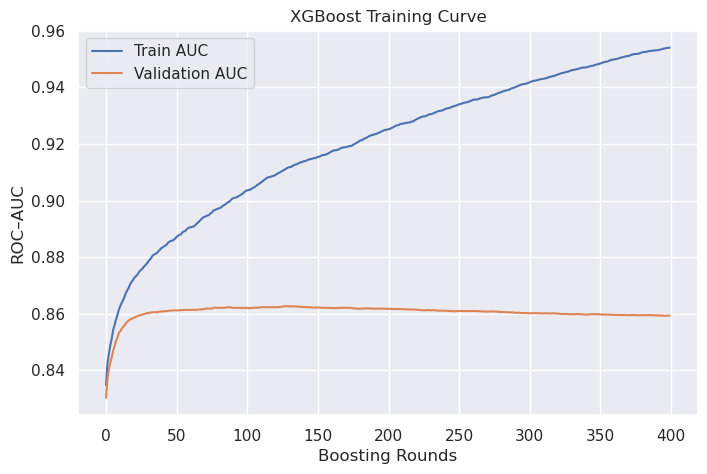

In [37]:
# Rebuild an XGB model with AUC metric and eval_set for the curve
xgb_curve = XGBClassifier(
    random_state=123,
    eval_metric="auc",   # track ROC–AUC
    verbosity=0,
    n_estimators=400,    # you can match what you used before, or leave default
)

# Use the same scaled train/test split as in earlier evaluations
eval_set = [
    (X_train_scaled, y_train),          # training set
    (X_test_split_scaled, y_test_split) # validation set
]

xgb_curve.fit(
    X_train_scaled,
    y_train,
    eval_set=eval_set,
    verbose=False
)

# Grab evaluation history and plot
results = xgb_curve.evals_result()

epochs = len(results["validation_0"]["auc"])
x_axis = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(x_axis, results["validation_0"]["auc"], label="Train AUC")
plt.plot(x_axis, results["validation_1"]["auc"], label="Validation AUC")
plt.xlabel("Boosting Rounds")
plt.ylabel("ROC–AUC")
plt.title("XGBoost Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
#Predict and Evaluation on train split data Set
y_pred = pipe_xgb.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
roc_score = roc_auc_score(y_train, y_pred)
print("XGB Train ROC Score:", roc_score)
print("XGB Train Accuracy:", accuracy)
print("XGB Train Precision:", precision)

#Predict and Evaluation on test split data Set
y_pred = pipe_xgb.predict(X_test_split_scaled)
accuracy = accuracy_score(y_test_split, y_pred)
precision = precision_score(y_test_split, y_pred)
roc_score = roc_auc_score(y_test_split, y_pred)
print("XGB Test ROC Score:", roc_score)
print("XGB Test Accuracy:", accuracy)
print("XGB Test Precision:", precision)

XGB Train ROC Score: 0.8205566001284734
XGB Train Accuracy: 0.8172349376785658
XGB Train Precision: 0.7616756800387441
XGB Test ROC Score: 0.780824835656717
XGB Test Accuracy: 0.7781614969232701
XGB Test Precision: 0.7220465836505581


In [39]:
# Predicting the test data
predicted = pipe_xgb.predict_proba(X_test_scaled)

# Exporting the predicted data to csv for Kaggle submission
pd.DataFrame(predicted[:,1], index = test_df.id).to_csv('xgb.csv', sep=',', index=True, encoding='utf-8')

In [40]:
#As in the Kaggle Competition, they evaluate the prediction with ROC curve,
# We are using scoring = "roc_auc" in our cross-validate function for checking the test score

def mean_std_cross_val_scores(model, X_train, y_train, scoring, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    #scores = cross_validate(model, X_train, y_train, **kwargs)

    scores = cross_validate(model, X_train, y_train, scoring=scoring, **kwargs)
    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" %
                       (mean_scores[i], std_scores[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [41]:
results_dict = {}  # dictionary to store all the results
#Making the model with best hyperparameter
models = {
    "decision tree": DecisionTreeClassifier(max_depth=7),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression":LogisticRegression(C=1.0, class_weight= "balanced"),
    "Random Forest Classifier":RandomForestClassifier(n_estimators=400, max_depth = 18,random_state=123),
    "LightGBM":LGBMClassifier(random_state=123),
    "XGB Boost":XGBClassifier(random_state=123, eval_metric="logloss", verbosity=0),
    
}

In [42]:
np.random.seed(12345)
for model in models:
    pipe = make_pipeline(models.get(model))
    results_dict[model] = mean_std_cross_val_scores(pipe, X_train_scaled, y_train, scoring = "roc_auc", cv=5, return_train_score=True)
    print(model)
    print(results_dict[model]  )

decision tree
fit_time       0.425 (+/- 0.003)
score_time     0.010 (+/- 0.000)
test_score     0.835 (+/- 0.001)
train_score    0.841 (+/- 0.001)
dtype: object
kNN
fit_time        0.013 (+/- 0.000)
score_time     16.527 (+/- 0.016)
test_score      0.802 (+/- 0.002)
train_score     0.904 (+/- 0.001)
dtype: object
Logistic Regression
fit_time       0.156 (+/- 0.004)
score_time     0.009 (+/- 0.000)
test_score     0.834 (+/- 0.003)
train_score    0.834 (+/- 0.001)
dtype: object
Random Forest Classifier
fit_time       65.346 (+/- 2.553)
score_time      2.161 (+/- 0.017)
test_score      0.860 (+/- 0.001)
train_score     0.988 (+/- 0.000)
dtype: object
LightGBM
fit_time       2.091 (+/- 0.060)
score_time     0.211 (+/- 0.003)
test_score     0.864 (+/- 0.001)
train_score    0.879 (+/- 0.000)
dtype: object
XGB Boost
fit_time       13.755 (+/- 0.149)
score_time      0.084 (+/- 0.001)
test_score      0.864 (+/- 0.001)
train_score     0.909 (+/- 0.001)
dtype: object


In [43]:
pd.DataFrame(results_dict).T

,fit_time,score_time,test_score,train_score
decision tree,0.425 (+/- 0.003),0.010 (+/- 0.000),0.835 (+/- 0.001),0.841 (+/- 0.001)
kNN,0.013 (+/- 0.000),16.527 (+/- 0.016),0.802 (+/- 0.002),0.904 (+/- 0.001)
Logistic Regression,0.156 (+/- 0.004),0.009 (+/- 0.000),0.834 (+/- 0.003),0.834 (+/- 0.001)
Random Forest Classifier,65.346 (+/- 2.553),2.161 (+/- 0.017),0.860 (+/- 0.001),0.988 (+/- 0.000)
LightGBM,2.091 (+/- 0.060),0.211 (+/- 0.003),0.864 (+/- 0.001),0.879 (+/- 0.000)
XGB Boost,13.755 (+/- 0.149),0.084 (+/- 0.001),0.864 (+/- 0.001),0.909 (+/- 0.001)


We tried to check the cross validation score for all of our models.
 The test score that we got form our cross validation,

| Model | ROC-Score |
| --- | ----------- |
| Decission Tree | 0.835 |
| kNN | 0.802 |
| Logistic Regression | 0.834 |
| Random Forest | 0.860 |
| XGBoost | 0.864 |
| LightBGM | 0.864 |


 The test score that we got form the Kaggle,

| Model | ROC-Score |
| --- | ----------- |
| Decission Tree | 0.838 |
| kNN | 0.795 |
| Logistic Regression | 0.837 |
| Random Forest | 0.862 |
| XGBoost | 0.866 |
| LightBGM | 0.866 |

We got similar test score values from cross-validation and Kaggle.

# 5. Results and Evaluation

We evaluated each model using two complementary approaches:

1. **Cross-validation on the training data**: Using 5-fold cross-validation with ROC-AUC scoring on the scaled training features.
2. **Submission to Kaggle**: Generating predicted probabilities for the test set, uploading them to Kaggle, and recording the public leaderboard ROC-AUC scores.

The cross-validated ROC-AUC scores on the training data were:

- Decision Tree: 0.835  
- kNN: 0.802  
- Logistic Regression: 0.834  
- Random Forest: 0.860  
- XGBoost: 0.864  
- LightGBM: 0.864  

The corresponding Kaggle ROC-AUC scores were very similar:

- Decision Tree: 0.838  
- kNN: 0.795  
- Logistic Regression: 0.837  
- Random Forest: 0.862  
- XGBoost: 0.866  
- LightGBM: 0.866  

These results show that tree-based ensemble methods (Random Forest, XGBoost, and LightGBM) clearly outperform simpler baselines like kNN and logistic regression on this problem. The fact that the cross-validated ROC-AUC scores closely match the Kaggle scores suggests that our validation strategy is reliable and that we are not severely overfitting to the training data.

We also examined detailed metrics (accuracy, precision, and ROC-AUC) for XGBoost on the train and validation splits. The model achieved strong performance on both splits, and the training vs. validation ROC-AUC curve remained stable across boosting rounds. This further supports the conclusion that our best models generalize well to unseen data.


# 6. Theoretical Background and Future Work

ROC-AUC is a natural choice for this competition because it evaluates how well the model ranks smokers above non-smokers across all possible probability thresholds. Unlike accuracy, which depends on a single threshold, ROC-AUC is threshold-independent and is less sensitive to class imbalance. A ROC-AUC of around 0.86-0.87 for our best models indicates that, given a random smoker and a random non-smoker, the model will assign a higher predicted score to the smoker roughly 86-87% of the time.

Tree-based ensembles such as Random Forest, XGBoost, and LightGBM perform well here because they can automatically capture nonlinear relationships and interactions between health variables (for example, how combinations of age, blood pressure, and cholesterol levels relate to smoking status). Logistic regression serves as a strong linear baseline and is more interpretable, but its performance is slightly lower because it assumes a mainly linear relationship between the features and the log-odds of smoking.

There are several promising directions for future work. First, we could perform more systematic hyperparameter tuning for the gradient boosting models (e.g., learning rate, maximum depth, number of leaves, and subsampling parameters) using random search or Bayesian optimization. Second, we could explore additional feature engineering, such as creating composite risk scores, interaction terms, or non-linear transformations for skewed variables. Finally, we could investigate calibration methods to ensure that predicted probabilities are well calibrated, which would be important if the model were to be used in real clinical decision-making.


## Deliverables Overview

# Deliverable 1, 2, and 3 (30% of Total Project)

    Lead Contributor: Akshay Mhetre
    Completed six non-dummy models independently, accounting for 10% each deliverable.

# Deliverable 4: Presentation (40% of Total Project)
    4a. Documentation and Slide Preparation (10%)

    Contributors: Alex Patel, Moffit Anderson, Edwin
    Developed comprehensive presentation materials and visual documentation

    4b. Presentation Delivery (30%)

    Primary Presenter: Edwin Lotsu
    Supporting Contributors: Team members provided additional input and support

# Deliverable 5: Report (30% of Total Project)

    Lead Contributors: Alex Patel, Moffit Anderson
    Collaborated on execution and completion
